# E-Commerce Sales & Customer Analytics EDA
This notebook explores the cleaned dataset generated by `python/data_cleaning.py` and the RFM segmentation generated by `python/customer_segmentation.py`.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
orders = pd.read_csv(DATA / 'orders_clean.csv', parse_dates=['order_date'])
segments = pd.read_csv(DATA / 'customer_segments.csv', parse_dates=['last_purchase_date'])
completed = orders.query("status == 'Completed'").copy()
completed.head()

,order_id,order_date,order_year,order_month,order_week,customer_id,customer_name,gender,age,city,...,discount_amount,gross_revenue,revenue,cost,shipping_cost,profit,profit_margin,payment_method,status,customer_order_count
0,765,2024-01-01,2024,2024-01,1,146,Customer_0146,Non-binary,58,Essaouira,...,8.24,206,197.76,96.88,9.52,91.36,46.20,Cash on Delivery,Completed,1
1,848,2024-01-01,2024,2024-01,1,1,Customer_0001,Male,27,Girona,...,6.32,158,151.68,78.34,7.50,65.84,43.41,Digital Wallet,Completed,8
2,848,2024-01-01,2024,2024-01,1,1,Customer_0001,Male,27,Girona,...,30.00,300,270.00,165.16,10.00,94.84,35.13,Digital Wallet,Completed,8
3,601,2024-01-02,2024,2024-01,1,224,Customer_0224,Non-binary,30,Annecy,...,9.45,135,125.55,160.71,9.75,-44.91,-35.77,Digital Wallet,Completed,3
4,601,2024-01-02,2024,2024-01,1,224,Customer_0224,Non-binary,30,Annecy,...,6.56,164,157.44,103.36,8.50,45.58,28.95,Digital Wallet,Completed,3


## Dataset Overview

In [2]:
overview = pd.Series({
    'line_items': len(orders),
    'unique_orders': completed['order_id'].nunique(),
    'unique_customers': completed['customer_id'].nunique(),
    'unique_products': completed['product_id'].nunique(),
    'date_start': completed['order_date'].min(),
    'date_end': completed['order_date'].max(),
    'missing_values': int(orders.isna().sum().sum()),
    'duplicate_rows': int(orders.duplicated().sum()),
})
overview

line_items                         2000
unique_orders                       695
unique_customers                    267
unique_products                      50
date_start          2024-01-01 00:00:00
date_end            2024-12-30 00:00:00
missing_values                        0
duplicate_rows                        0
dtype: object

## KPI Snapshot

In [3]:
kpis = pd.Series({
    'Total Revenue': round(completed['revenue'].sum(), 2),
    'Total Profit': round(completed['profit'].sum(), 2),
    'Total Orders': int(completed['order_id'].nunique()),
    'Total Units Sold': int(completed['quantity'].sum()),
    'Average Order Value': round(completed['revenue'].sum() / completed['order_id'].nunique(), 2),
    'Average Profit per Order': round(completed['profit'].sum() / completed['order_id'].nunique(), 2),
})
kpis

Total Revenue               284741.58
Total Profit                 53643.61
Total Orders                   695.00
Total Units Sold              4848.00
Average Order Value            409.70
Average Profit per Order        77.19
dtype: float64

## Monthly Trends

In [4]:
monthly = (completed.groupby('order_month', as_index=False)
           .agg(revenue=('revenue', 'sum'), profit=('profit', 'sum'), orders=('order_id', 'nunique'))
           .sort_values('order_month'))
monthly['mom_revenue_growth_pct'] = monthly['revenue'].pct_change().mul(100).round(2)
monthly

,order_month,revenue,profit,orders,mom_revenue_growth_pct
0,2024-01,28473.40,4697.84,69,NaN
1,2024-02,21428.65,4598.59,47,-24.74
2,2024-03,24894.53,4207.19,65,16.17
3,2024-04,25603.13,6059.06,57,2.85
4,2024-05,21088.97,3446.84,51,-17.63
5,2024-06,20911.98,4120.86,55,-0.84
6,2024-07,22063.70,5138.87,42,5.51
7,2024-08,25156.36,5503.42,66,14.02
8,2024-09,21611.66,3430.23,58,-14.09
9,2024-10,28484.78,6275.32,70,31.80


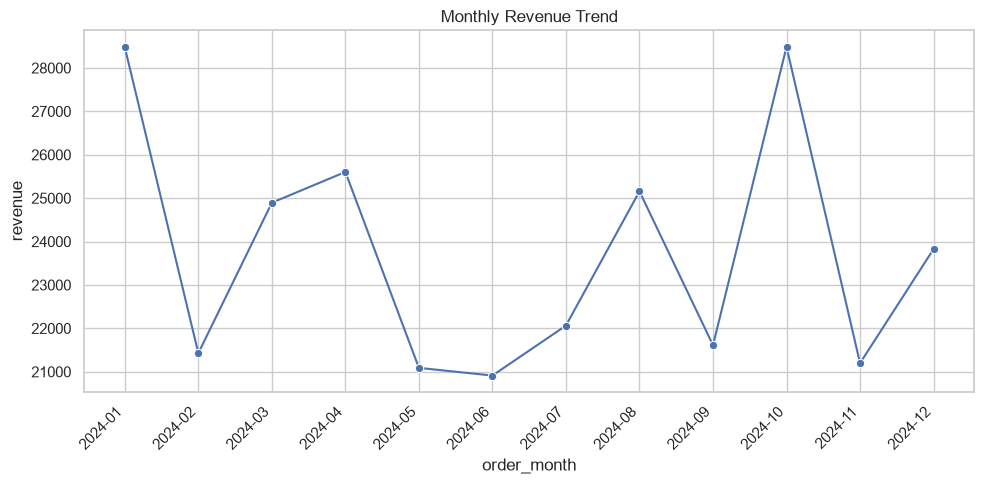

In [5]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x='order_month', y='revenue', marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue Trend')
plt.tight_layout()

## Product Performance

In [6]:
product_perf = (completed.groupby(['product_name', 'category'], as_index=False)
                .agg(revenue=('revenue', 'sum'), profit=('profit', 'sum'), units=('quantity', 'sum')))
top_products = product_perf.sort_values('revenue', ascending=False).head(10)
top_products

,product_name,category,revenue,profit,units
7,Product_16,Makeup,8954.41,1287.18,135
39,Product_45,Body,8793.63,891.68,154
17,Product_25,Hair,8646.84,1204.44,131
15,Product_23,Body,8643.67,2577.02,132
46,Product_6,Body,7853.24,1463.70,132
41,Product_47,Hair,7423.81,1165.31,128
4,Product_13,Skin,7389.65,1792.83,113
33,Product_4,Body,7106.45,2068.04,120
25,Product_32,Body,7067.79,1405.03,131
5,Product_14,Body,6813.79,2320.25,100


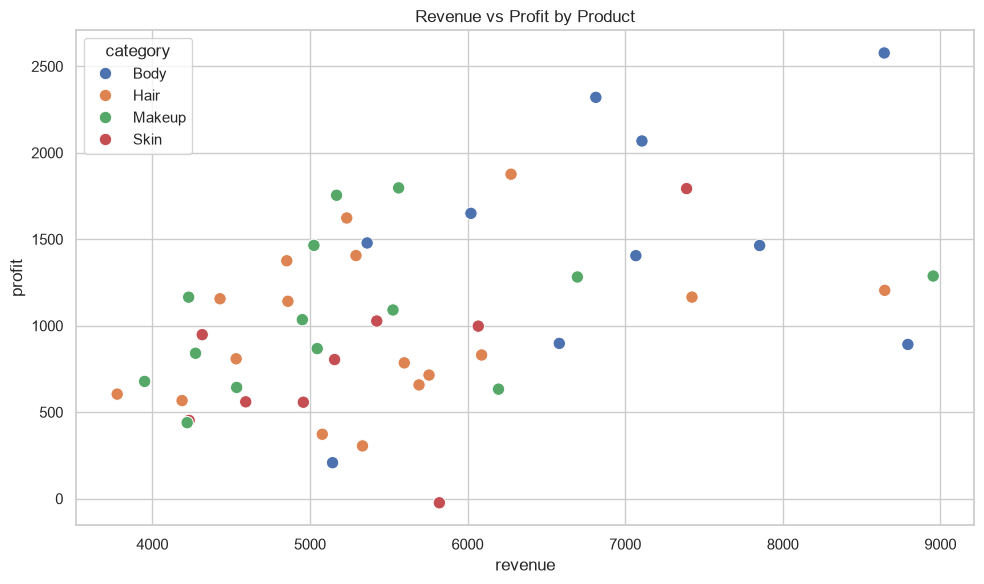

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=product_perf, x='revenue', y='profit', hue='category', s=80)
plt.title('Revenue vs Profit by Product')
plt.tight_layout()

## Customer and Segment Analysis

In [8]:
segment_summary = (segments.groupby('segment', as_index=False)
                   .agg(customers=('customer_id', 'count'), revenue=('total_revenue', 'sum'))
                   .sort_values('revenue', ascending=False))
segment_summary

,segment,customers,revenue
1,Champions,45,95192.31
0,At Risk,45,57814.18
3,Loyal Customers,45,56559.01
2,Lost Customers,87,49000.75
5,Potential Loyalists,36,22809.18
4,New Customers,9,3366.15


C:\Users\tanis\AppData\Local\Temp\ipykernel_9788\481424994.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, x='segment', y='revenue', palette='viridis')


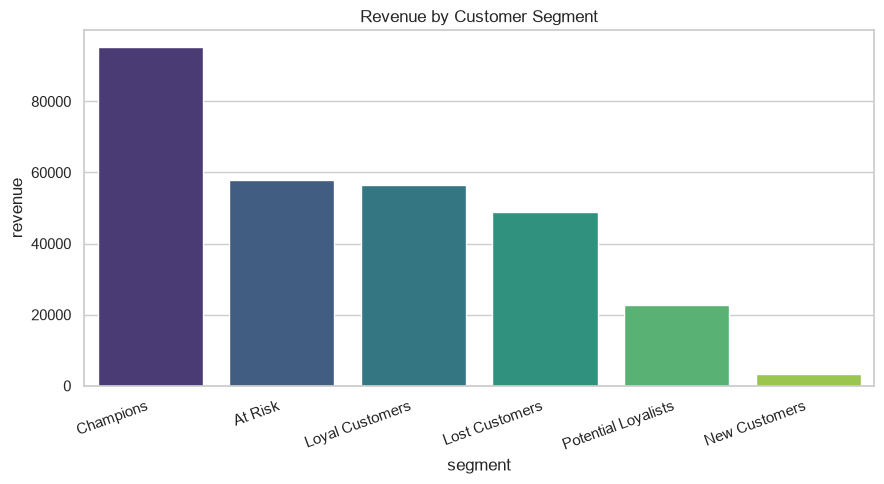

In [9]:
plt.figure(figsize=(9, 5))
sns.barplot(data=segment_summary, x='segment', y='revenue', palette='viridis')
plt.xticks(rotation=20, ha='right')
plt.title('Revenue by Customer Segment')
plt.tight_layout()

## Geographic Analysis
The enriched customer dimension adds city, state, and region labels so the public dataset can support regional dashboard views and Power BI slicers.

In [10]:
geo = (completed.groupby(['region', 'state'], as_index=False)
       .agg(revenue=('revenue', 'sum'), profit=('profit', 'sum'), orders=('order_id', 'nunique'))
       .sort_values('revenue', ascending=False))
geo.head(10)

,region,state,revenue,profit,orders
8,Southern Europe,Catalonia,27646.27,7016.75,64
10,Southern Europe,Lombardy,26823.97,6289.29,60
13,Western Europe,Ile-de-France,23799.23,5309.50,59
5,North Africa,Rabat-Sale-Kenitra,23085.59,3785.37,50
9,Southern Europe,Lazio,22454.80,3578.78,54
6,Southern Europe,Andalusia,21030.53,3395.71,59
4,North Africa,Marrakesh-Safi,20216.54,4761.41,44
14,Western Europe,Provence-Alpes-Cote d'Azur,18870.57,4278.42,40
0,Central Europe,Bavaria,18021.05,3176.30,47
3,North Africa,Casablanca-Settat,16244.54,2332.24,40
